In [1]:
import functional_functions as ff
from nilearn.maskers import SurfaceLabelsMasker
from nilearn.connectome import ConnectivityMeasure, vec_to_sym_matrix, sym_matrix_to_vec
from nilearn.surface import SurfaceImage
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from nilearn.plotting import plot_connectome, view_connectome

/srv/conda/envs/notebook/lib/python3.10/site-packages/google/api_core/_python_version_support.py:255: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
pixdim[1,2,3] should be non-zero; setting 0 dims to 1


# Get the Data

## Load the data from shared folder

In [2]:
data_path = Path("/home/jovyan/shared/data/td-brain") / "training_corrmats_all.npy"
corr_mat = np.load(data_path)
corr_mat.shape

(692, 64981)

## Remove the first column of each array (subjects id)

In [3]:
corr_mat_ids = corr_mat[:, :1].astype(int)
corr_mat_no_id = corr_mat[:, 1:]

corr_mat_no_id.shape

(692, 64980)

## Discard the diagonal

In [4]:
n_nodes = 360

def drop_diagonal(vec_with_diag, n_nodes=360):
    matrices = vec_to_sym_matrix(vec_with_diag) 
    return sym_matrix_to_vec(matrices, discard_diagonal=True)

corr_mat_noDiag = drop_diagonal(corr_mat_no_id, n_nodes)
corr_mat_noDiag.shape

(692, 64620)

# Prepare the data

## z-transform the matrices

In [5]:
corr_mat_zScore = np.arctanh(corr_mat_noDiag)
np.shape(corr_mat_zScore)

(692, 64620)

## Load the sociodemographics

In [6]:
sociodem_df = pd.read_csv("train_split.csv")
delayed_discount_df = pd.read_csv("DD_AUC_targets.csv")

In [7]:
train_df = sociodem_df.merge(
    delayed_discount_df[["Subject", "DDisc_AUC_40K"]],
    on="Subject",
    how="left"
)

train_df = train_df[["Subject", "Gender", "Age", "DDisc_AUC_40K"]]
train_df

,Subject,Gender,Age,DDisc_AUC_40K
0,519647,M,26-30,0.100391
1,308129,M,22-25,0.831641
2,837560,M,26-30,0.227084
3,523032,M,31-35,0.885938
4,200614,F,31-35,0.499219
...,...,...,...,...
686,580650,F,31-35,0.080990
687,125525,F,31-35,0.555860
688,205725,F,22-25,0.804818
689,194746,M,31-35,0.870573


## Merge corr matraces with sociodemographics

In [8]:
# Bring corr_mat_ids and _zScores into dataframes
corr_mat_ids_df = pd.DataFrame(corr_mat_ids, columns=["Subject"])

corr_mat_zScore_df = pd.DataFrame(corr_mat_zScore)

corr_mat_zScore_df.columns

RangeIndex(start=0, stop=64620, step=1)

In [9]:
# Bring corr_mat_ids and _zScores into dataframes
corr_mat_ids_df = pd.DataFrame(corr_mat_ids, columns=["Subject"])

corr_mat_zScore_df = pd.DataFrame(corr_mat_zScore)

# Add back the corr_mat labels
import labels as lb

# Create lookup table
lut = ff.create_mmp_lookup()

# Rename columns with prefixes
corr_mat_zScore_df.columns = [
    f"{lb.get_labels_of_index(i, lut)}"
    for i in corr_mat_zScore_df.columns
]

# Store all connectivity variable names in one list
connectivity_vars = (
    corr_mat_zScore_df.columns.tolist()
)

# merge them
corr_mat_zScore_id_df = corr_mat_ids_df.join(corr_mat_zScore_df)

corr_mat_zScore_id_df

,Subject,ROI 1: L_MST | ROI 2: L_V1,ROI 1: L_V6 | ROI 2: L_V1,ROI 1: L_V6 | ROI 2: L_MST,ROI 1: L_V2 | ROI 2: L_V1,ROI 1: L_V2 | ROI 2: L_MST,ROI 1: L_V2 | ROI 2: L_V6,ROI 1: L_V3 | ROI 2: L_V1,ROI 1: L_V3 | ROI 2: L_MST,ROI 1: L_V3 | ROI 2: L_V6,...,ROI 1: R_p24 | ROI 2: R_p10p,ROI 1: R_p24 | ROI 2: R_p47r,ROI 1: R_p24 | ROI 2: R_TGv,ROI 1: R_p24 | ROI 2: R_MBelt,ROI 1: R_p24 | ROI 2: R_LBelt,ROI 1: R_p24 | ROI 2: R_A4,ROI 1: R_p24 | ROI 2: R_STSva,ROI 1: R_p24 | ROI 2: R_TE1m,ROI 1: R_p24 | ROI 2: R_PI,ROI 1: R_p24 | ROI 2: R_a32pr
0,163129,0.132101,0.146091,1.603905,1.110573,-0.130835,-0.131569,0.421498,1.334274,1.349956,...,2.201454,2.236028,-1.539670,-1.582493,1.709353,2.102953,1.578077,1.707525,0.639734,1.654159
1,308129,0.780898,1.562151,0.669198,2.479964,0.767234,1.678677,1.549977,0.880691,1.227709,...,2.492147,2.467078,1.998977,0.186072,1.731614,2.482837,2.054021,0.845449,1.813271,1.709369
2,529953,0.151329,0.520031,1.025373,1.137482,-0.255290,0.174107,1.054645,0.101990,0.424547,...,1.902019,2.227548,1.500035,1.814953,1.744737,1.712765,2.356556,2.007970,1.253896,1.683845
3,523032,1.431399,-0.368959,-0.616712,1.549129,1.165729,-0.186658,1.857160,1.761290,-0.512372,...,1.998391,1.886105,1.420979,-1.515448,-0.336125,1.675547,-0.887414,-1.830138,-0.036639,1.551245
4,103818,0.941414,1.151969,0.797668,0.736646,0.653387,0.730726,-0.161074,0.078411,-0.019427,...,1.521811,1.493517,1.369341,-0.642146,-0.070179,1.297456,-1.449586,1.257125,0.680511,1.318578
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
687,187547,-0.053006,0.549707,-0.038814,1.489700,-0.205644,0.511159,0.742438,-0.951645,0.362646,...,0.052858,0.043767,0.056428,0.080501,0.096474,0.051240,0.068160,0.012713,0.060017,0.143803
688,978578,0.863363,-0.498795,-1.472985,1.053940,0.277364,0.036701,1.073743,1.661449,-1.242550,...,-2.062679,-1.977177,-1.707319,-1.305074,-1.711601,-1.678103,-1.839434,2.154487,-1.514051,-1.504571
689,205725,1.627411,-0.065188,-0.261277,1.046754,0.654069,0.354225,1.503574,1.111578,0.098534,...,-0.681419,-0.714799,-0.699052,-0.660081,0.686335,-0.422512,-0.692976,0.718577,-0.699257,-0.622327
690,185038,-1.334677,-1.048129,1.981017,0.427200,0.039564,0.173465,0.741818,-0.318475,-0.187918,...,1.887621,2.108099,2.001780,-0.918754,-1.510568,-1.421983,1.369184,-2.023056,-1.318424,-0.405962


In [10]:
merged_df = (
    train_df
    .merge(corr_mat_zScore_id_df, on="Subject", how="left")
)

merged_df

,Subject,Gender,Age,DDisc_AUC_40K,ROI 1: L_MST | ROI 2: L_V1,ROI 1: L_V6 | ROI 2: L_V1,ROI 1: L_V6 | ROI 2: L_MST,ROI 1: L_V2 | ROI 2: L_V1,ROI 1: L_V2 | ROI 2: L_MST,ROI 1: L_V2 | ROI 2: L_V6,...,ROI 1: R_p24 | ROI 2: R_p10p,ROI 1: R_p24 | ROI 2: R_p47r,ROI 1: R_p24 | ROI 2: R_TGv,ROI 1: R_p24 | ROI 2: R_MBelt,ROI 1: R_p24 | ROI 2: R_LBelt,ROI 1: R_p24 | ROI 2: R_A4,ROI 1: R_p24 | ROI 2: R_STSva,ROI 1: R_p24 | ROI 2: R_TE1m,ROI 1: R_p24 | ROI 2: R_PI,ROI 1: R_p24 | ROI 2: R_a32pr
0,519647,M,26-30,0.100391,0.491604,1.860610,0.446891,2.337998,0.501220,1.807321,...,2.264766,2.156504,2.177905,1.315466,1.893233,2.191786,1.344485,1.990852,1.810121,2.255966
1,308129,M,22-25,0.831641,0.780898,1.562151,0.669198,2.479964,0.767234,1.678677,...,2.492147,2.467078,1.998977,0.186072,1.731614,2.482837,2.054021,0.845449,1.813271,1.709369
2,837560,M,26-30,0.227084,-0.276561,0.853873,-0.841922,1.272583,-0.653802,1.429930,...,1.910158,1.881538,1.867512,0.432121,0.412292,1.941996,-1.334595,1.869319,1.847818,1.920768
3,523032,M,31-35,0.885938,1.431399,-0.368959,-0.616712,1.549129,1.165729,-0.186658,...,1.998391,1.886105,1.420979,-1.515448,-0.336125,1.675547,-0.887414,-1.830138,-0.036639,1.551245
4,200614,F,31-35,0.499219,-0.992230,1.299904,-1.645951,1.621055,-1.555031,1.980514,...,2.150863,2.144932,1.941968,1.600177,1.564732,-1.762662,2.009018,1.999289,-1.219998,0.378260
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
686,580650,F,31-35,0.080990,1.898847,-1.049311,-1.070365,2.595453,1.827936,-1.051009,...,-0.632780,-0.706797,-0.705389,-0.633959,-0.646141,-0.698717,-0.703320,0.711070,-0.707749,0.413009
687,125525,F,31-35,0.555860,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
688,205725,F,22-25,0.804818,1.627411,-0.065188,-0.261277,1.046754,0.654069,0.354225,...,-0.681419,-0.714799,-0.699052,-0.660081,0.686335,-0.422512,-0.692976,0.718577,-0.699257,-0.622327
689,194746,M,31-35,0.870573,0.798147,0.768168,1.897988,1.620593,0.995483,0.928208,...,0.690363,0.677774,0.736885,0.788292,0.528645,0.661937,0.610742,-0.627002,0.635853,0.890760


# Analysis

## Define the predictors

In [11]:
demographic_vars = ['Gender', 'Age']

## Transform ordinal data

In [12]:
age_ranges = merged_df["Age"].unique()
age_ranges

array(['26-30', '22-25', '31-35', '36+'], dtype=object)

In [13]:
age_mapping = {age: i for i, age in enumerate(age_ranges)}
merged_df["Age_ordinal"] = merged_df["Age"].map(age_mapping)
merged_df

,Subject,Gender,Age,DDisc_AUC_40K,ROI 1: L_MST | ROI 2: L_V1,ROI 1: L_V6 | ROI 2: L_V1,ROI 1: L_V6 | ROI 2: L_MST,ROI 1: L_V2 | ROI 2: L_V1,ROI 1: L_V2 | ROI 2: L_MST,ROI 1: L_V2 | ROI 2: L_V6,...,ROI 1: R_p24 | ROI 2: R_p47r,ROI 1: R_p24 | ROI 2: R_TGv,ROI 1: R_p24 | ROI 2: R_MBelt,ROI 1: R_p24 | ROI 2: R_LBelt,ROI 1: R_p24 | ROI 2: R_A4,ROI 1: R_p24 | ROI 2: R_STSva,ROI 1: R_p24 | ROI 2: R_TE1m,ROI 1: R_p24 | ROI 2: R_PI,ROI 1: R_p24 | ROI 2: R_a32pr,Age_ordinal
0,519647,M,26-30,0.100391,0.491604,1.860610,0.446891,2.337998,0.501220,1.807321,...,2.156504,2.177905,1.315466,1.893233,2.191786,1.344485,1.990852,1.810121,2.255966,0
1,308129,M,22-25,0.831641,0.780898,1.562151,0.669198,2.479964,0.767234,1.678677,...,2.467078,1.998977,0.186072,1.731614,2.482837,2.054021,0.845449,1.813271,1.709369,1
2,837560,M,26-30,0.227084,-0.276561,0.853873,-0.841922,1.272583,-0.653802,1.429930,...,1.881538,1.867512,0.432121,0.412292,1.941996,-1.334595,1.869319,1.847818,1.920768,0
3,523032,M,31-35,0.885938,1.431399,-0.368959,-0.616712,1.549129,1.165729,-0.186658,...,1.886105,1.420979,-1.515448,-0.336125,1.675547,-0.887414,-1.830138,-0.036639,1.551245,2
4,200614,F,31-35,0.499219,-0.992230,1.299904,-1.645951,1.621055,-1.555031,1.980514,...,2.144932,1.941968,1.600177,1.564732,-1.762662,2.009018,1.999289,-1.219998,0.378260,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
686,580650,F,31-35,0.080990,1.898847,-1.049311,-1.070365,2.595453,1.827936,-1.051009,...,-0.706797,-0.705389,-0.633959,-0.646141,-0.698717,-0.703320,0.711070,-0.707749,0.413009,2
687,125525,F,31-35,0.555860,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
688,205725,F,22-25,0.804818,1.627411,-0.065188,-0.261277,1.046754,0.654069,0.354225,...,-0.714799,-0.699052,-0.660081,0.686335,-0.422512,-0.692976,0.718577,-0.699257,-0.622327,1
689,194746,M,31-35,0.870573,0.798147,0.768168,1.897988,1.620593,0.995483,0.928208,...,0.677774,0.736885,0.788292,0.528645,0.661937,0.610742,-0.627002,0.635853,0.890760,2


In [14]:
# IMPORTANT: Do this after mapping and transforming the ordinal data, so that unmapped/unexpected strings in 
#            that step that became silently NaN are removed

# Clean
cleaned_df = merged_df.dropna(subset=connectivity_vars + ['Age_ordinal', 'Gender'])
cleaned_df = cleaned_df.copy() # Because otherwise numpy will complain later 'cause it doesn't know if it should also change the 'mother' train data
print(f"Usable training subjects: {len(cleaned_df)} out of {len(merged_df)}")

Usable training subjects: 657 out of 691


## Create dummy variables for categorical data

In [15]:
# Define categorical variables
categorical_cols = ['Gender']

# Dummy code
final_df = pd.get_dummies(
    cleaned_df,
    columns=categorical_cols,
    drop_first=True
)

final_df

,Subject,Age,DDisc_AUC_40K,ROI 1: L_MST | ROI 2: L_V1,ROI 1: L_V6 | ROI 2: L_V1,ROI 1: L_V6 | ROI 2: L_MST,ROI 1: L_V2 | ROI 2: L_V1,ROI 1: L_V2 | ROI 2: L_MST,ROI 1: L_V2 | ROI 2: L_V6,ROI 1: L_V3 | ROI 2: L_V1,...,ROI 1: R_p24 | ROI 2: R_TGv,ROI 1: R_p24 | ROI 2: R_MBelt,ROI 1: R_p24 | ROI 2: R_LBelt,ROI 1: R_p24 | ROI 2: R_A4,ROI 1: R_p24 | ROI 2: R_STSva,ROI 1: R_p24 | ROI 2: R_TE1m,ROI 1: R_p24 | ROI 2: R_PI,ROI 1: R_p24 | ROI 2: R_a32pr,Age_ordinal,Gender_M
0,519647,26-30,0.100391,0.491604,1.860610,0.446891,2.337998,0.501220,1.807321,2.350437,...,2.177905,1.315466,1.893233,2.191786,1.344485,1.990852,1.810121,2.255966,0,True
1,308129,22-25,0.831641,0.780898,1.562151,0.669198,2.479964,0.767234,1.678677,1.549977,...,1.998977,0.186072,1.731614,2.482837,2.054021,0.845449,1.813271,1.709369,1,True
2,837560,26-30,0.227084,-0.276561,0.853873,-0.841922,1.272583,-0.653802,1.429930,0.797967,...,1.867512,0.432121,0.412292,1.941996,-1.334595,1.869319,1.847818,1.920768,0,True
3,523032,31-35,0.885938,1.431399,-0.368959,-0.616712,1.549129,1.165729,-0.186658,1.857160,...,1.420979,-1.515448,-0.336125,1.675547,-0.887414,-1.830138,-0.036639,1.551245,2,True
4,200614,31-35,0.499219,-0.992230,1.299904,-1.645951,1.621055,-1.555031,1.980514,1.485093,...,1.941968,1.600177,1.564732,-1.762662,2.009018,1.999289,-1.219998,0.378260,2,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
685,415837,22-25,0.711719,0.456525,-1.034431,-0.170608,2.029662,0.486191,-0.926971,0.624783,...,-0.122186,1.652966,1.445290,-0.992902,1.739485,-0.665040,1.720104,1.771391,1,False
686,580650,31-35,0.080990,1.898847,-1.049311,-1.070365,2.595453,1.827936,-1.051009,2.485672,...,-0.705389,-0.633959,-0.646141,-0.698717,-0.703320,0.711070,-0.707749,0.413009,2,False
688,205725,22-25,0.804818,1.627411,-0.065188,-0.261277,1.046754,0.654069,0.354225,1.503574,...,-0.699052,-0.660081,0.686335,-0.422512,-0.692976,0.718577,-0.699257,-0.622327,1,False
689,194746,31-35,0.870573,0.798147,0.768168,1.897988,1.620593,0.995483,0.928208,0.316161,...,0.736885,0.788292,0.528645,0.661937,0.610742,-0.627002,0.635853,0.890760,2,True


## Elastic Net Pipeline

### Load sklearn modules

In [16]:
from sklearn.model_selection import KFold
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import ElasticNetCV
from sklearn.preprocessing import StandardScaler

In [17]:
continuous_cols = ['Age_ordinal'] + connectivity_vars
feature_cols = ['Gender_M'] + continuous_cols

In [18]:
X = final_df[feature_cols]
y = final_df["DDisc_AUC_40K"]

## K-Fold Parameters

In [22]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# store out-of-fold predictions here — one prediction per subject
oof_predictions = np.full(len(X), np.nan)
fold_r2_scores = []

## Quickcheck the shape of the data

In [23]:
print(X.shape, y.shape)
print(X.index.equals(y.index))

(657, 64622) (657,)
True


# Run over folds

In [22]:
fold_coefs = []

for fold_num, (train_idx, val_idx) in enumerate(kf.split(X)):
    X_tr, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    scaler = StandardScaler()
    X_tr[continuous_cols] = scaler.fit_transform(X_tr[continuous_cols])
    X_val[continuous_cols] = scaler.transform(X_val[continuous_cols])

    # Tuning happens HERE, using only this fold's training data
    model = ElasticNetCV(l1_ratio=[.1, .5, .7, .9, .95, .99, 1],
                          alphas=np.logspace(-3, 1, 50),
                          cv=5, random_state=42, max_iter=10000,
                        n_jobs=-1)
    model.fit(X_tr, y_tr)

    preds = model.predict(X_val)
    oof_predictions[val_idx] = preds
    fold_r2_scores.append(model.score(X_val, y_val))
    print(f"Fold {fold_num + 1}: R² = {fold_r2_scores[-1]:.4f}, "
          f"alpha={model.alpha_:.4f}, l1_ratio={model.l1_ratio_}")
    fold_coefs.append(model.coef_)

print(f"Mean CV R²: {np.mean(fold_r2_scores):.4f} (+/- {np.std(fold_r2_scores):.4f})")

Fold 1: R² = 0.0181, alpha=0.4095, l1_ratio=0.1
Fold 2: R² = 0.0130, alpha=0.3393, l1_ratio=0.1
Fold 3: R² = 0.0170, alpha=0.4095, l1_ratio=0.1
Fold 4: R² = 0.0125, alpha=0.3393, l1_ratio=0.1
Fold 5: R² = 0.0645, alpha=0.0244, l1_ratio=1.0
Mean CV R²: 0.0250 (+/- 0.0198)


## Check overall out-of-fold correlation

In [23]:
from scipy.stats import pearsonr
r, p_val = pearsonr(y, oof_predictions)
print(f"Out-of-fold r = {r:.3f}, p = {p_val:.3f}")

Out-of-fold r = 0.165, p = 0.000


## Save the data

In [25]:
import joblib

results = {
    'oof_predictions': oof_predictions,
    'y_true': y.values,
    'fold_r2_scores': fold_r2_scores,
    'fold_coefs': np.array(fold_coefs),
}

joblib.dump(results, 'elasticnet_5kfold_ddisc_results.pkl')

['elasticnet_5kfold_ddisc_results.pkl']

## Plot the results

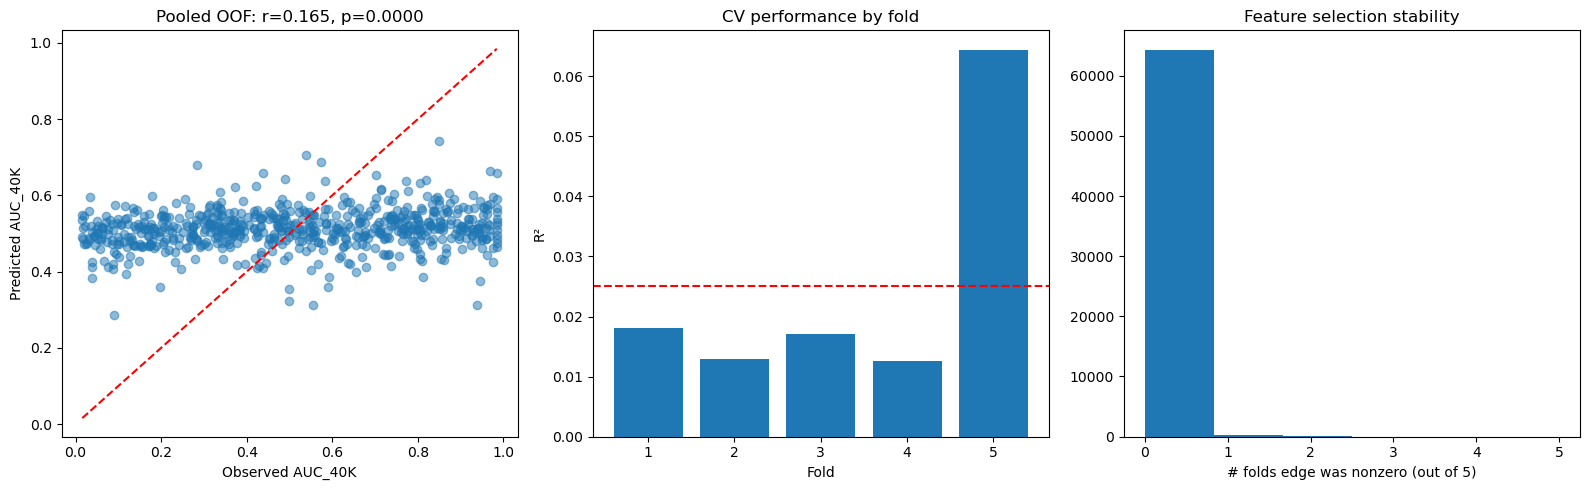

In [26]:
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# (a) Predicted vs actual, pooled out-of-fold
r, p = pearsonr(y, oof_predictions)
axes[0].scatter(y, oof_predictions, alpha=0.5)
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
axes[0].set_xlabel('Observed AUC_40K')
axes[0].set_ylabel('Predicted AUC_40K')
axes[0].set_title(f'Pooled OOF: r={r:.3f}, p={p:.4f}')

# (b) Fold-by-fold R²
axes[1].bar(range(1, len(fold_r2_scores)+1), fold_r2_scores)
axes[1].axhline(np.mean(fold_r2_scores), color='r', linestyle='--')
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('R²')
axes[1].set_title('CV performance by fold')

# (c) Coefficient stability: how many folds selected each edge as nonzero
nonzero_counts = (np.array(fold_coefs) != 0).sum(axis=0)
axes[2].hist(nonzero_counts, bins=6)
axes[2].set_xlabel('# folds edge was nonzero (out of 5)')
axes[2].set_title('Feature selection stability')

plt.tight_layout()
plt.show()

## Fit the final model

In [19]:
final_scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[continuous_cols] = final_scaler.fit_transform(X[continuous_cols])

final_model = ElasticNetCV(
    l1_ratio=[.1, .5, .7, .9, .95, .99, 1],
    alphas=np.logspace(-3, 1, 50),
    cv=5,
    random_state=42,
    max_iter=10000,
    n_jobs=-1
)

final_model.fit(X_scaled, y)

print(f"Final alpha: {final_model.alpha_:.4f}")
print(f"Final l1_ratio: {final_model.l1_ratio_}")

Final alpha: 0.2330
Final l1_ratio: 0.1


## Save the data

In [20]:
import joblib

results = {
    'final_coefs': final_model.coef_,
    'final_alpha': final_model.alpha_,
    'final_l1_ratio': final_model.l1_ratio_,
    'feature_cols': feature_cols,
    'final_scaler': final_scaler,
}

joblib.dump(results, 'elasticnet_final_ddisc_results.pkl')

['elasticnet_final_ddisc_results.pkl']

# Visualization

## Visualize the Top N contributing features

In [21]:
coefs = final_model.coef_
feature_names = np.array(feature_cols)

n_nonzero = np.sum(coefs != 0)
print(f"{n_nonzero} of {len(coefs)} features have nonzero coefficients")

171 of 64622 features have nonzero coefficients


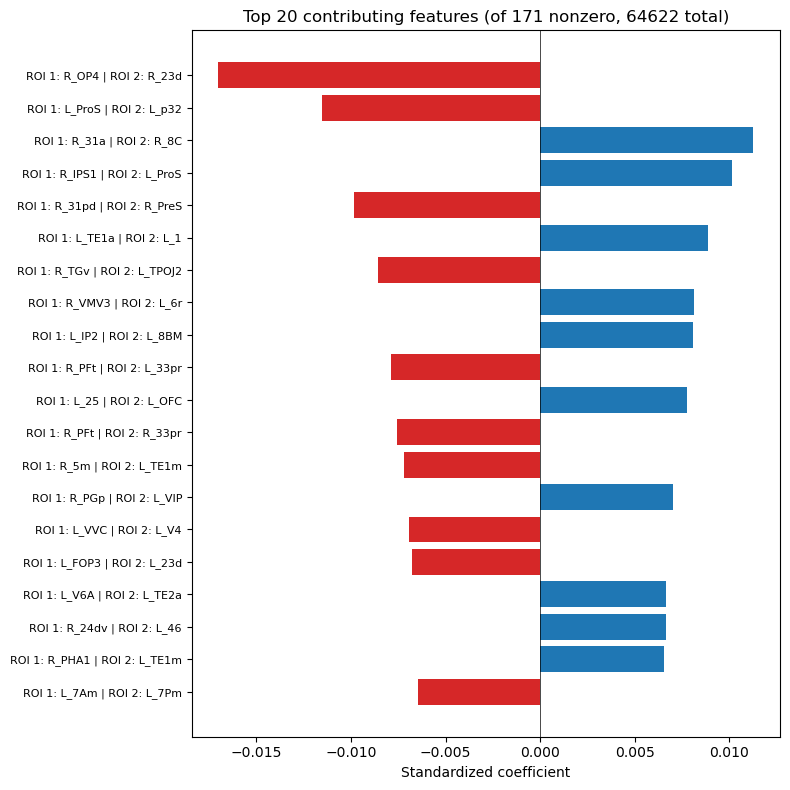

In [22]:
N = min(20, n_nonzero)  # don't show more than actually survived selection
idx_sorted = np.argsort(np.abs(coefs))[::-1][:N]

top_names = feature_names[idx_sorted]
top_vals = coefs[idx_sorted]

plt.figure(figsize=(8, 8))
colors = ['#d62728' if v < 0 else '#1f77b4' for v in top_vals]
plt.barh(range(N), top_vals[::-1], color=colors[::-1])
plt.yticks(range(N), top_names[::-1], fontsize=8)
plt.xlabel('Standardized coefficient')
plt.title(f'Top {N} contributing features (of {n_nonzero} nonzero, {len(coefs)} total)')
plt.axvline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

In [24]:
# 1. Separate out the connectivity coefficients from the covariate ones
#    (feature_cols = ['Gender_M', 'Age_ordinal'] + connectivity_vars, based on your notebook)
n_covariates = 2  # Gender_M, Age_ordinal
edge_coefs = final_model.coef_[n_covariates:]  # length should be 64620

print(len(edge_coefs))  # sanity check: should be 64620

# 2. Reconstruct the 360x360 matrix from the edge vector
#    vec_to_sym_matrix needs the diagonal supplied separately since edge_coefs excludes it
coef_matrix = vec_to_sym_matrix(edge_coefs, diagonal=np.zeros(360))
print(coef_matrix.shape)  # (360, 360)

# 3. Get node coordinates — you'll need MNI (x,y,z) per Glasser-360 region
#    Check whether your lookup table (lut / functional_functions) already has these
coords = ff.get_mmp_coordinates(lut)  # <- adjust to whatever function/attribute actually holds coordinates in your lut

# 4. Plot only the strongest edges (otherwise 64,620 edges = unreadable mess)
plot_connectome(
    coef_matrix,
    coords,
    edge_threshold="99.5%",   # keeps only the strongest ~0.5% of edges — adjust to taste
    title="Top edges predicting AUC_40K",
    node_size=15,
    colorbar=True
)
plt.show()

64620
(360, 360)


AttributeError: module 'functional_functions' has no attribute 'get_mmp_coordinates'